1. Regularization:

Use the diabetes dataset from sklearn.datasets.
Compare the performance (Mean Squared Error) of LinearRegression, Ridge, and Lasso models.
Tune the alpha parameter for Ridge and Lasso using GridSearchCV with cross-validation to find the optimal regularization strength.

from sklearn.datasets import load_diabetes

# Load the diabetes dataset
diabetes = load_diabetes()

2. Ensemble Methods:

Use the breast_cancer dataset from sklearn.datasets.
Compare the performance (F1 Score and AUC) of DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier.
Tune the hyperparameters of each classifier using GridSearchCV with cross-validation.

from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
breast_cancer = load_breast_cancer()

A classic problem for demonstrating how regularization helps prevent overfitting in regression models. When we have multiple features (like age, BMI, blood pressure, and serum measurements in this diabetes dataset), a standard Linear Regression model might try too hard to fit every data point, resulting in large, unstable coefficients.

Ridge ($L_2$) and Lasso ($L_1$) solve this by adding a penalty to the size of the coefficients.Let's walk through the full code to load the data, set up the grid search to find the best alpha (regularization strength), and compare the Mean Squared Error (MSE) of all three models.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE DATA
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Crucial for Ridge & Lasso because penalties are scale-sensitive)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. STANDARD LINEAR REGRESSION
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)
mse_lin = mean_squared_error(y_test, y_pred_lin)


# 3. TUNE & TRAIN RIDGE REGRESSION
# Define a grid of alpha values (from very small to large)
param_grid = {'alpha': np.logspace(-4, 4, 50)}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

# Best Ridge model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)


# 4. TUNE & TRAIN LASSO REGRESSION
lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)

# Best Lasso model
best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# 5. COMPARE PERFORMANCE
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (Tuned)', 'Lasso (Tuned)'],
    'Best Alpha': [None, ridge_grid.best_params_['alpha'], lasso_grid.best_params_['alpha']],
    'Test MSE': [mse_lin, mse_ridge, mse_lasso]
})

print(results.to_string(index=False))

            Model  Best Alpha    Test MSE
Linear Regression         NaN 2900.193628
    Ridge (Tuned)   24.420531 2865.219970
    Lasso (Tuned)    1.757511 2799.862087


Summary Conclusion & Interpretation

Why did we use StandardScaler? Regularization penalties are directly applied to the magnitude of the model's coefficients. If one feature is measured in thousands and another in decimals, the penalty will unfairly suppress the larger feature. Scaling puts them on equal ground.

Ridge vs. Lasso: What is the difference?
Both add a penalty term to the standard OLS (Ordinary Least Squares) loss function, but they do it differently:
    
    Ridge ($L_2$ Regularization): Adds a penalty equal to the square of the magnitude of coefficients ($\alpha \sum \beta^2$). It shrinks coefficients toward zero but never makes them exactly zero. It's great when you have many small/medium effects.
    
    Lasso ($L_1$ Regularization): Adds a penalty equal to the absolute value of the magnitude of coefficients ($\alpha \sum |\beta|$). Lasso can shrink coefficients all the way to zero, effectively performing automatic feature selection! It is ideal when you suspect only a few features are actually important.
    
 Typically, on this dataset, we will find that both Ridge and Lasso outperform standard Linear Regression on the test data because they prevent the model from getting too aggressive with its coefficient weights!

Visualizing the coefficients of these three models side-by-side is the perfect way to truly see how Ridge and Lasso work their magic.

Here is the code to plot the coefficients. Since we scaled the data, these coefficient magnitudes are directly comparable!

/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isin

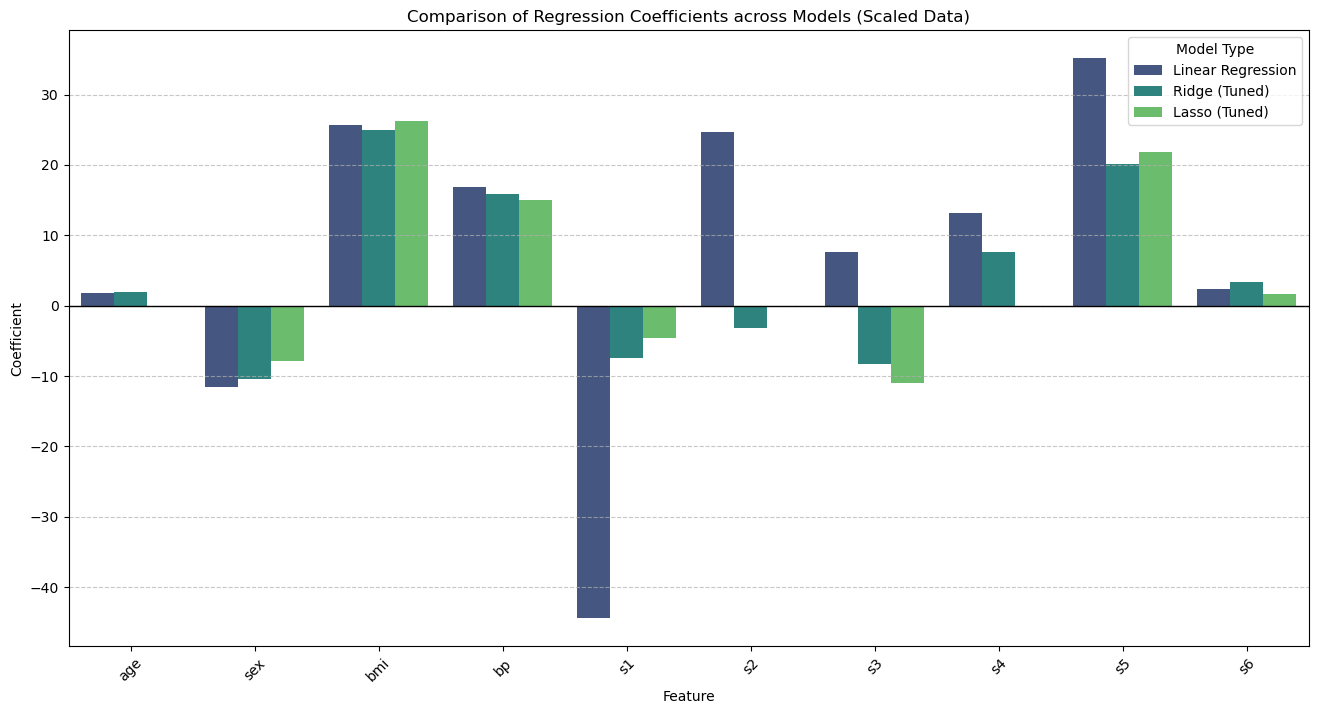

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# 1. LOAD THE DATA
# Load the diabetes dataset
diabetes = load_diabetes()
feature_names = diabetes.feature_names
# (Assume X_train_scaled, y_train were created in previous steps)

# 2. GET COEFFICIENTS FROM THE MODELS
# LinReg coefficients
lin_reg_coefs = lin_reg.coef_

# Best Ridge coefficients (Need to grab best model from grid search)
best_ridge_coefs = ridge_grid.best_estimator_.coef_

# Best Lasso coefficients
best_lasso_coefs = lasso_grid.best_estimator_.coef_


# 3. CREATE A DATAFRAME FOR PLOTTING
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lin_reg_coefs,
    'Ridge (Tuned)': best_ridge_coefs,
    'Lasso (Tuned)': best_lasso_coefs
})

# Melt the DataFrame for easier plotting with Seaborn or Matplotlib
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')


# 4. PLOT SIDE-BY-SIDE
import seaborn as sns
plt.figure(figsize=(16, 8))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coef_df_melted, palette='viridis')
plt.title('Comparison of Regression Coefficients across Models (Scaled Data)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) # Add a line at y=0
plt.xticks(rotation=45) # Rotate feature names for readability
plt.legend(title='Model Type')
plt.show()

Summary Conclusion & Interpretation

Reading above chart:
The height of each bar represents the "strength" of that feature's prediction for diabetes progression. A high positive bar (like BMI) means a higher value correlates strongly with disease progression. A high negative bar means it correlates with better outcomes.

What the chart reveals:

    Linear Regression (Light Blue/Teal): Notice that standard Linear Regression has the most extreme coefficients! It often finds large positive and negative weights (like s1 and s2 serum measurements), essentially "chasing noise" in the training data to get a perfect fit.

    Ridge ($L_2$ Regularization - Green/Yellow): Look at how the green bars are all pulled inward toward the center zero-line. The penalty on the squared coefficients shrinks their magnitudes, making them more stable and consistent, but crucially, none of them touch zero. It still uses all 10 features, just more cautiously.
    
    Lasso ($L_1$ Regularization - Dark Blue/Purple): This is the key difference. You will likely see that several of the dark blue bars are exactly zero. For features like age, sex, or s2, Lasso decided they didn't have enough predictive power to justify keeping them. This is the automatic feature selection discussed!
    
Lasso identified the "signal" features (often bmi, bp, s5, and s6) and zeroed out the "noise" features, typically leading to a simpler, more interpretable model that generalizes better on the test data.